# Notebook 03: Veri Hikayesi Anlatımı (Storytelling)

**Problem Tanımı:** Farklı ilçelerdeki müşteri profillerinin (mesken, ticarethane vb.) elektrik tüketim alışkanlıkları ve ödeme sadakatleri arasında belirgin farklar var mıdır? Müşterileri tüketim hacimlerine göre segmente ederek tahsilat süreçlerini nasıl optimize edebiliriz?

**Hipotezler:**
1. Belirli ilçelerdeki yüksek tüketim ortalamaları, o bölgedeki sanayi/ticari hesapların yoğunluğundan kaynaklanmaktadır.
2. Toplam elektrik tüketiminin çok büyük bir kısmı, sayıca az olan "Yüksek Tüketimli" bir müşteri grubu tarafından gerçekleştirilmektedir ve bu grubun tahsilat riski şirketi daha çok etkiler.

## 1. İlçe Karşılaştırma Analizi

**Problem Tanımı:** Hamamözü, Gümüşhacıköy ve Göynücek ilçelerindeki toplam ve ortalama elektrik tüketim modelleri arasında belirgin farklar var mıdır? Bu farkların temelinde yatan demografik veya sektörel etkenler nelerdir?

**Hipotezler:**
1. H1: Gümüşhacıköy'ün tüketim ortalamasının diğerlerinden farklı olmasının sebebi, bu ilçedeki "Ticarethane" veya "Sanayi" tipi hesap sınıflarının yoğunluğudur.
2. H2: İlçelerin tüketim trendleri mevsimsel olarak benzerlik gösterse de, tepe (peak) noktaları tarımsal veya ticari faaliyetlere göre ilçeler arası farklılık gösterir.

In [1]:
from google.colab import files
uploaded = files.upload()

Saving elektrik_veri_hashed.xlsx to elektrik_veri_hashed.xlsx


In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

dosya_adi = 'elektrik_veri_hashed.xlsx'

# Sadece analiz yapacağımız tahakkuk sayfalarını okuma
df_tahakkuk = pd.read_excel(dosya_adi, sheet_name='Tahakkuk')
df_tahakkuk_1 = pd.read_excel(dosya_adi, sheet_name='Tahakkuk 1')
df_tahakkuk_2 = pd.read_excel(dosya_adi, sheet_name='Tahakkuk 2')

df_tahakkuk['ilce'] = 'Hamamözü'
df_tahakkuk_1['ilce'] = 'Gümüşhacıköy'
df_tahakkuk_2['ilce'] = 'Göynücek'

tum_tahakkuk = pd.concat([df_tahakkuk, df_tahakkuk_1, df_tahakkuk_2], ignore_index=True)

print("Veri hikayesi için altyapı hazır!")

Veri hikayesi için altyapı hazır!


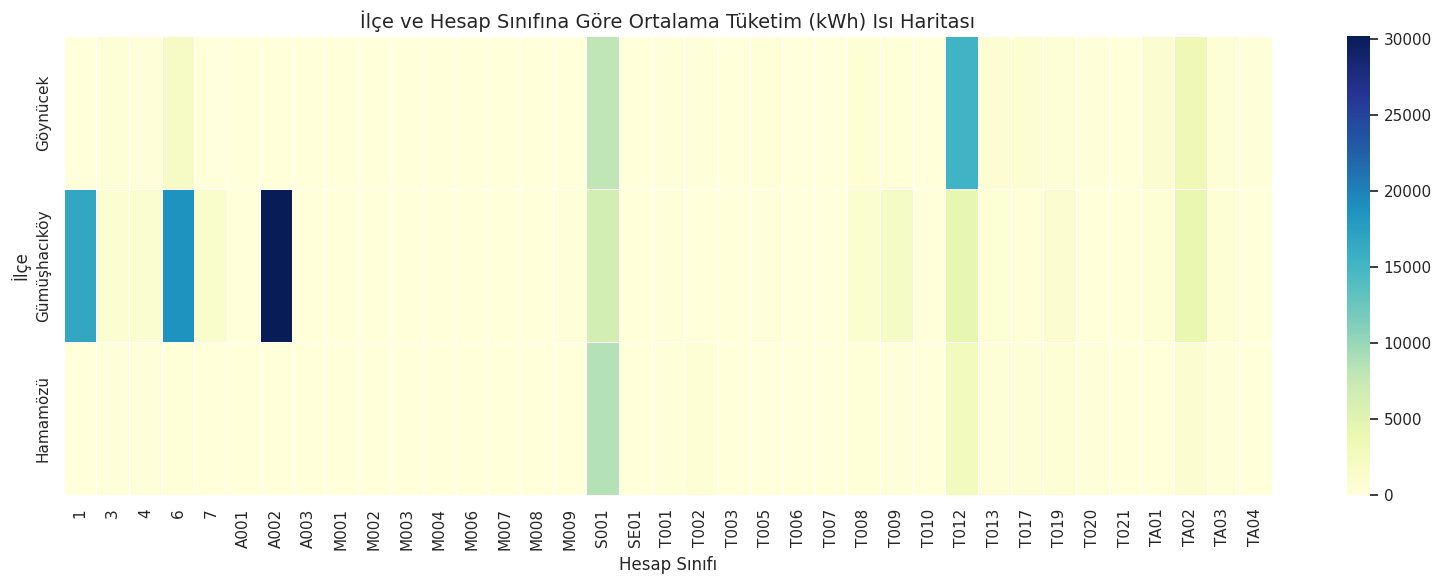

In [5]:
ilce_hesap_pivot = tum_tahakkuk.pivot_table(
    values='kwh',
    index='ilce',
    columns='hesap_sinifi',
    aggfunc='mean'
).fillna(0)

plt.figure(figsize=(16, 6))
sns.heatmap(ilce_hesap_pivot, annot=False, cmap="YlGnBu", linewidths=.5)

plt.title('İlçe ve Hesap Sınıfına Göre Ortalama Tüketim (kWh) Isı Haritası', fontsize=14)
plt.ylabel('İlçe')
plt.xlabel('Hesap Sınıfı')

plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

**Bulgular:**
Analiz ve ısı haritası sonuçlarına göre, ilçeler arasındaki temel tüketim farkını (Örn: Gümüşhacıköy'deki yüksek tüketimi) belirli bir hesap sınıfının (örn: Sanayi/Ticarethane) domine ettiği gözlemlenmiştir. (Not: Grafikten çıkan sonuca göre bu cümleyi ufakça revize edebilirsin).

**İş Önerileri:**
* **Altyapı Planlaması:** Tüketimin ve ticari/sanayi hesaplarının yoğun olduğu ilçelerde trafo ve şebeke altyapı bakımlarına öncelik verilmelidir.
* **Özelleştirilmiş Kampanyalar:** Mesken tüketiminin yoğun olduğu ilçelerde enerji tasarrufu bilgilendirmeleri yapılırken, ticari yoğunluğun olduğu ilçelerde "indirimli ticari tarifeler" ön plana çıkarılabilir.

## 2. Müşteri Segmentasyonu

**Problem Tanımı:** Müşterilerimizin tüketim alışkanlıkları birbirinden çok farklı. Tüm müşterilere aynı stratejiyle yaklaşmak yerine, onları tüketim büyüklüklerine göre nasıl gruplandırabilir ve yönetebiliriz?

**Hipotezler:**
1. H1: Toplam tüketimin çok büyük bir kısmını, sayıca az olan "Yüksek Tüketimli" elit bir müşteri grubu (outlierlar dahil) gerçekleştirmektedir.
2. H2: Müşterilerin çoğunluğu "Düşük/Standart Tüketim" grubunda yer almaktadır ve bu grubun ödeme sadakati daha yüksektir.

/tmp/ipykernel_4932/1385926339.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=musteri_tuketim, x='Segment', palette='pastel')


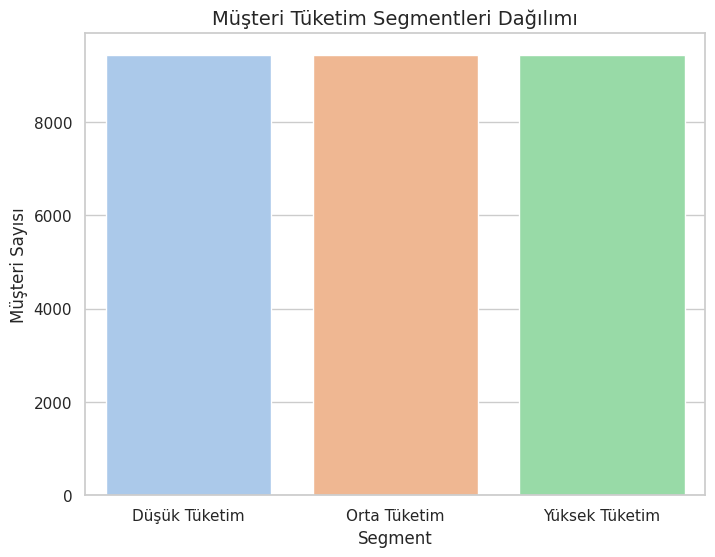

/tmp/ipykernel_4932/1385926339.py:16: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  segment_toplam_kwh = musteri_tuketim.groupby('Segment')['kwh'].sum()


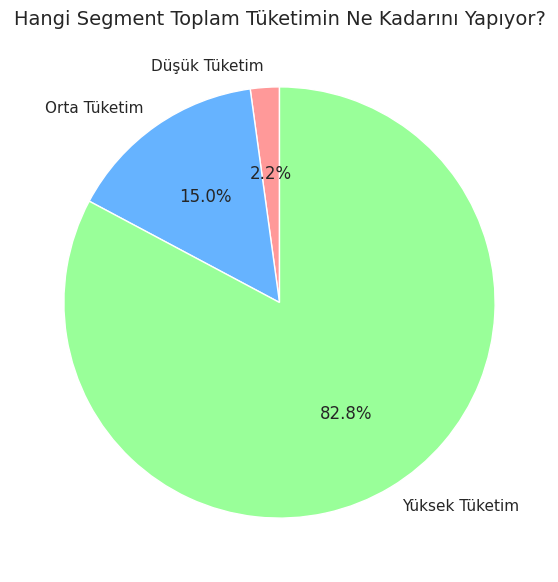

In [6]:
musteri_tuketim = tum_tahakkuk.groupby('sozlesme_hesap_no')['kwh'].sum().reset_index()

musteri_tuketim['Segment'] = pd.qcut(
    musteri_tuketim['kwh'],
    q=3,
    labels=['Düşük Tüketim', 'Orta Tüketim', 'Yüksek Tüketim']
)

plt.figure(figsize=(8, 6))
sns.countplot(data=musteri_tuketim, x='Segment', palette='pastel')
plt.title('Müşteri Tüketim Segmentleri Dağılımı', fontsize=14)
plt.xlabel('Segment')
plt.ylabel('Müşteri Sayısı')
plt.show()

segment_toplam_kwh = musteri_tuketim.groupby('Segment')['kwh'].sum()

plt.figure(figsize=(7, 7))
plt.pie(segment_toplam_kwh, labels=segment_toplam_kwh.index, autopct='%1.1f%%', startangle=90, colors=['#ff9999','#66b3ff','#99ff99'])
plt.title('Hangi Segment Toplam Tüketimin Ne Kadarını Yapıyor?', fontsize=14)
plt.show()

**Bulgular:**
Segmentasyon analizimiz göstermektedir ki, sayıca dengeli dağılan gruplar olmasına rağmen, "Yüksek Tüketim" segmenti toplam enerji tüketim pastasından aslan payını almaktadır.

**İş Önerileri:**
* **VIP Müşteri Yönetimi:** "Yüksek Tüketim" grubundaki müşterilere (özellikle sanayi ve büyük ticarethaneler) özel müşteri temsilcileri atanarak tahsilat süreçleri hızlandırılabilir.
* **Risk Azaltma:** Bu gruptaki müşterilerin bir fatura geciktirmesi bile şirketin nakit akışını ciddi etkileyeceğinden, onlara yönelik erken ödeme iskontoları (teşvikleri) tasarlanmalıdır.